# 3 Apr 2026
- basic notebook that samples IPTA MDC1 in sqrtspharm broadband basis using discovery -- new specspat formalism

In [2]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## broadband analysis

In [100]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 6 # freq components
lmx = 4
nsi=1
nblms = (lmx+1)**2-1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})


psrpos = np.array([p.pos for p in psrs])

sqrtsphorf = dac.get_sqrtspharm_orf(psrpos, lmax=lmx)

glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.powerlaw],
                                    [[sqrtsphorf]],
                                    components=comps, T=T, name='gw', nbasis=[[nblms]])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    paramdict[f'gw_blm({nblms})'] = params[:nblms]
    paramdict['gw_gamma'] = params[-2]
    paramdict['gw_log10_A'] = params[-1]
    return m_mdc.logL(paramdict)
    

In [101]:
mdc_jlogl.params

['J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 'J1022+1001_rednoise_gamma',
 'J1022+1001_rednoise_log10_A',
 'J1024-0719_rednoise_gamma',
 'J1024-0719_rednoise_log10_A',
 'J1045-4509_rednoise_gamma',
 'J1045-4509_rednoise_log10_A',
 'J1455-3330_rednoise_gamma',
 'J1455-3330_rednoise_log10_A',
 'J1600-3053_rednoise_gamma',
 'J1600-3053_rednoise_log10_A',
 'J1603-7202_rednoise_gamma',
 'J1603-7202_rednoise_log10_A',
 'J1640+2224_rednoise_gamma',
 'J1640+2224_rednoise_log10_A',
 'J1643-

In [122]:
nparams = nblms + 2

tstpars = np.zeros(nparams)
tstpars[-2] = 13/3
tstpars[-1] = -16

constrn_like(tstpars)

Array(-78083.70989644, dtype=float64)

In [103]:
%timeit constrn_like(tstpars).block_until_ready()

4.59 ms ± 39.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [127]:
l10apri = lambda x: jss.uniform.logpdf(x, -18, 6)
gampri = lambda x: jss.uniform.logpdf(x, 0, 7)
bl0pri = lambda x: jss.uniform.logpdf(x, 0, 50)
blm_amp_pri = lambda x: jss.uniform.logpdf(x, 0, 50)
blm_phase_pri = lambda x: jss.uniform.logpdf(x, 0, 2*jnp.pi)

m0ampidx = []
lmampidx = []
lmphsidx = []
for i in range(1, lmx+1):
    m0ampidx.append(i**2-1)
    lmpars = np.arange(i**2, (i+1)**2-1, dtype=int)
    lmampidx.extend(int(x) for x in lmpars[0::2])
    lmphsidx.extend(int(x) for x in lmpars[1::2])

m0ampidx = np.array(m0ampidx)
lmampidx = np.array(lmampidx)
lmphsidx = np.array(lmphsidx)


@jax.jit
def priorfunc(params):
    blms = params[:nblms]
    gamma = params[-2]
    log10A = params[-1]
    gamprival = gampri(gamma)
    l10Aprival = l10apri(log10A)

    bl0prival = bl0pri(blms[m0ampidx])
    blmamp_prival = blm_amp_pri(blms[lmampidx])
    blmphs_prival = blm_phase_pri(blms[lmphsidx])
    blmprival = np.sum(bl0prival) + np.sum(blmamp_prival) + np.sum(blmphs_prival)
    fullpri = blmprival + gamprival + l10Aprival
    return fullpri

# rawblmpri = lambda x: jss.uniform.logpdf(x, -5, 10)

# @jax.jit
# def priorfunc(params):
#     blms = params[:nblms]
#     gamma = params[-2]
#     log10A = params[-1]
#     clmprival = jnp.sum(rawblmpri(blms))
#     gamprival = gampri(gamma)
#     l10Aprival = l10apri(log10A)
#     fullpri = clmprival + gamprival + l10Aprival
#     return fullpri


In [128]:
priorfunc(tstpars)

Array(-76.88476236, dtype=float64)

In [124]:
tstpars[0] = 10
print(tstpars)
constrn_like(tstpars)

[ 10.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.           0.           0.           0.           4.33333333
 -16.        ]


Array(-78368.79151991, dtype=float64)

In [106]:
%timeit priorfunc(tstpars).block_until_ready()

16.9 μs ± 95.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [129]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [ ]:
initcov = np.eye(nparams) * 0.01
sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
                                   #logl_grad=likegradjump, logp_grad=prigradjump, 
                                   cov=initcov,
                                   outDir=f'./chains/sqrtspharm_broad_lm{lmx}_{comps}f_tst/', resume=False)

In [ ]:
sampler.sample(Niter=10000, p0=np.array(tstpars),
               SCAMweight=25, AMweight=25, DEweight=50)

Resuming run from chain file ./chains/sqrtspharm_broad_lm4_6f_tst//chain_1.txt
Resuming with 1001 samples from file representing 10001 original samples
Adding DE jump with weight 50
Finished 100.00 percent (100.00 percent of new work) in 42.624612 s Acceptance rate = 0.444099
Run Complete


## Looking at the chain

In [138]:
chn = np.loadtxt('/home/levis/ipta_aniso_datachallenge/examples/chains/sqrtspharm_broad_lm4_6f_tst/chain_1.txt')

In [139]:
chn.shape

(2001, 30)

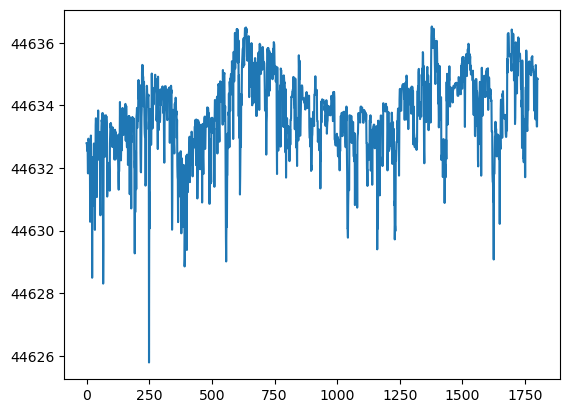

In [140]:
plt.plot(chn[200:, -4])

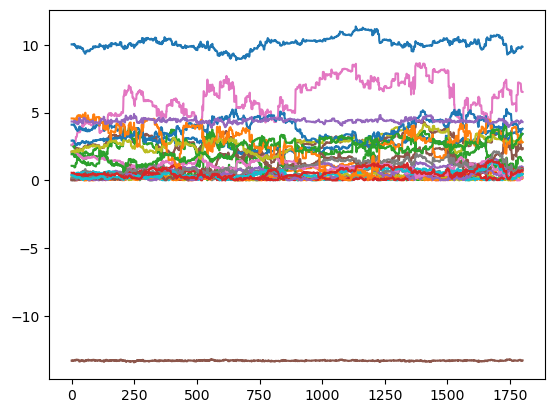

In [141]:
for i in range(nparams):
    plt.plot(chn[200:, i])

In [142]:
truevals = np.zeros(50)
truevals[-2] = 13/3
truevals[-1] = -13.301029995663981

In [143]:
#corner(chn[2000:, :-4], truths=truevals);

In [41]:
injparams

{'gw_log10_A': np.float64(-13.301029995663981), 'gw_gamma': 4.333333333333333}

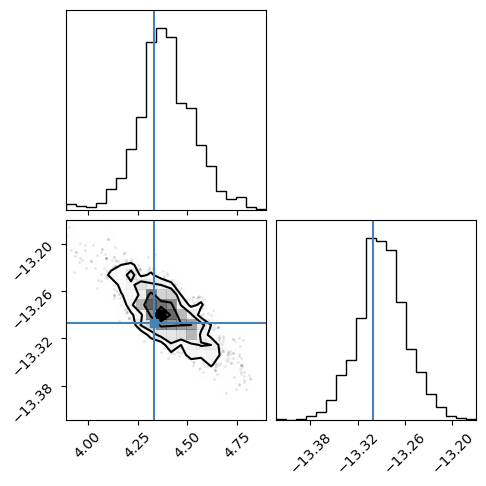

In [144]:
corner(chn[200:, -6:-4], truths=[13/3, -13.301029995663981]);

In [22]:
holdangpow = np.zeros((1000, lmx))
for i in range(1000):
    holdangpow[i,:] = dac.clm2angpowspec(chn[3000:, :nclms][i], lmax=lmx)

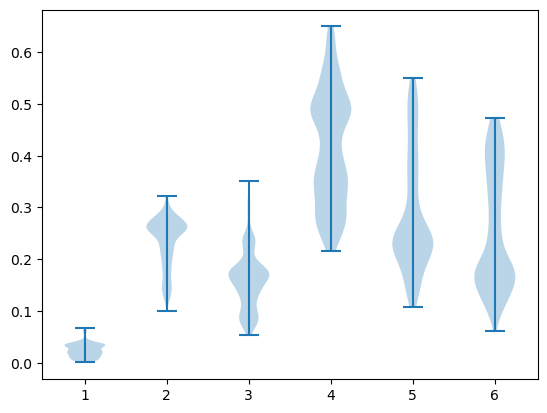

In [24]:
plt.violinplot(holdangpow/(4*np.pi), positions=np.arange(1, lmx+1));